# Réduire le détail des cartes de zones de livraison pour des tableaux de bord logistiques rapides avec PROC GREDUCE

## Synthèse

Un transporteur de colis régional stocke les limites de ses territoires de service sous forme de contours polygonaux denses, et les tableaux de bord de planification d'itinéraires les redessinent lentement. Ce notebook synthétise les coordonnées de contour de quatre zones de livraison, utilise **PROC GREDUCE** pour marquer chaque sommet de contour avec un niveau `DENSITY`, puis restitue une carte choroplèthe de la livraison à temps avec **PROC GMAP** à un niveau de détail réduit afin que la carte se dessine plus vite tout en gardant chaque zone reconnaissable.

GREDUCE a classé les 96 points de contour en trois paliers : 10 points à `DENSITY=0`, 44 à `DENSITY=2` et 42 à `DENSITY=3`. Ne garder que le palier grossier (`DENSITY <= 2`) fait passer la carte de 96 à 54 sommets — soit une réduction d'environ 44 % — et pourtant les quatre zones restent clairement identifiables dans la comparaison côte à côte ci-dessous.

## Sources de données

Toutes les données sont générées en ligne par les DATA steps ci-dessous — aucun fichier externe ni accès réseau.

| Jeu de données | Lignes | Variables clés | Description |
|---------|------|---------------|-------------|
| `zonemap` | 96 (4 zones x 24 sommets) | `zone` (ID), `x`, `y` | Coordonnées synthétiques de contour polygonal fermé pour quatre zones de service de livraison, chacune une ellipse perturbée tracée par 24 sommets afin que la réduction de densité ait matière à amincir. |
| `reducedmap` | 96 | ajoute `density` | Sortie de PROC GREDUCE : les points de contour marqués d'un niveau `DENSITY` (ici 0, 2 ou 3) pour un rendu sélectif. |
| `coarsemap` | 54 | sous-ensemble de `reducedmap` | Le sous-ensemble `DENSITY <= 2` — le palier grossier à rendu rapide utilisé pour la carte du tableau de bord en détail réduit. |
| `zonekpi` | 4 | `zone`, `ontime_rate`, `parcels` | Une ligne de réponse par zone : pourcentage synthétique de livraison à temps et volume quotidien de colis, jointe à la carte pour la choroplèthe. |

> **Remarque sur la taille de l'échantillon.** Cet environnement fonctionne sans licence, si bien que chaque DATA step est plafonné à 100 observations en sortie. La carte est dimensionnée à 4 zones x 24 sommets = 96 points afin que le territoire entier tienne sous ce plafond ; une installation sous licence tracerait des centaines de sommets par zone, un cas où GREDUCE est encore plus rentable.

# Réduire le détail des cartes de zones de livraison avec PROC GREDUCE

Les opérateurs logistiques visualisent la performance sur des cartes de leurs **territoires de service** — les zones géographiques dont un dépôt est responsable. Ces limites de zone sont souvent saisies à résolution de relevé : de nombreux sommets par polygone. Quand un tableau de bord de planification d'itinéraires redessine plusieurs zones à la fois, tout ce détail de sommets ralentit le rendu sans ajouter de valeur décisionnelle au niveau de zoom du tableau de bord.

**PROC GREDUCE** répond à ce problème. Elle examine chaque polygone et marque chaque point de contour d'un niveau `DENSITY`, où 0 signale les points qui définissent la forme essentielle et les niveaux supérieurs signalent un détail progressivement plus fin. En aval, on sélectionne un palier avec `WHERE density <= n` pour dessiner une carte en détail réduit qui se dessine vite tout en gardant chaque zone reconnaissable.

Dans ce notebook, nous :
1. Synthétisons les contours de quatre zones de livraison.
2. Exécutons PROC GREDUCE pour attribuer les niveaux `DENSITY`.
3. Examinons comment les points se répartissent entre les paliers de densité.
4. Restituons les choroplèthes de livraison à temps en détail complet et en détail réduit, puis les comparons.

## Étape 1 — Synthétiser la carte des contours de zone

Un jeu de données de carte SAS comporte une observation par **sommet de contour**, avec une variable `ID` nommant la zone et des coordonnées numériques `x`/`y`. Nous traçons chaque zone de livraison comme une ellipse perturbée à l'aide de 24 angles également espacés, afin que les polygones partent d'une densité raisonnable et que la réduction ait matière à travailler.

`call streaminit` fixe le flux aléatoire pour la reproductibilité, et `rand('uniform')` ajoute de petites irrégularités au contour afin que les tracés ressemblent à des territoires relevés sur le terrain plutôt qu'à des ellipses parfaites.

In [1]:
DONNÉES zonemap;
    APPELER streaminit(20260531);
    /* Four delivery zones, each a jittered ellipse of 24 vertices.
       cx/cy = zone center, rx/ry = nominal radii (territory size). */
    TABLEAU cx[4] _temporary_ (12 32 20 40);
    TABLEAU cy[4] _temporary_ (30 32 14 16);
    TABLEAU rx[4] _temporary_ ( 8  9  6  7);
    TABLEAU ry[4] _temporary_ ( 6  7  5  6);
    pi = constant('pi');
    nvtx = 23;                 /* 24 vertices (0..23) per outline */
    FAIRE zone = 1 JUSQU_À 4;
        FAIRE i = 0 JUSQU_À nvtx;
            ang = 2 * pi * i / (nvtx + 1);
            /* radial jitter: +/- ~6% irregular coastline-style edge */
            jit = 1 + 0.12 * (rand('uniform') - 0.5);
            x = cx[zone] + rx[zone] * cos(ang) * jit;
            y = cy[zone] + ry[zone] * sin(ang) * jit;
            SORTIE;
        FIN;
    FIN;
    GARDER zone x y;
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=zonemap n MIN MAX nmiss;
    CLASSE zone;
    VAR x y;
    ÉTIQUETTE zone="Zone"
              x="Coordonnée X"
              y="Coordonnée Y";
EXÉCUTER;

                                                  The MEANS Procedure

                                          Analysis Variable : x Coordonnée X

        Zone              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24      3.6053386     20.3284433              0
        2                    24     23.0107098     41.2087956              0
        3                    24     13.7607192     26.2351392              0
        4                    24     33.0535851     47.3028874              0
        --------------------------------------------------------------------

                                          Analysis Variable : y Coordonnée Y

        Zone              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24     23.9838655     35.9959368              0
  


NOTE: DATA zonemap


NOTE: Wrote zonemap (96 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Le tableau PROC MEANS confirme la géométrie synthétique : quatre zones, chacune avec exactement 24 points de contour sur des plages `x`/`y` cohérentes et aucune coordonnée manquante. Les quatre ellipses occupent des régions non chevauchantes (zone 1 près de x=12, zone 2 près de x=32, zones 3 et 4 plus bas), si bien que la choroplèthe se lira comme quatre territoires distincts. Ce sont ces contours que PROC GREDUCE va amincir.

## Étape 2 — Attribuer les niveaux DENSITY avec PROC GREDUCE

L'instruction `ID` nomme la variable qui définit chaque zone unitaire — ici `zone`. PROC GREDUCE évalue le polygone de chaque zone indépendamment (avec une simplification de type Douglas-Peucker) et réécrit le jeu de données d'entrée en y ajoutant une variable entière `density` : le niveau 0 marque les quelques points qui ancrent la forme essentielle, et les niveaux supérieurs marquent un détail progressivement plus fin que l'on peut retirer en premier.

Nous laissons GREDUCE dériver ses propres seuils à partir des données plutôt que d'imposer des tailles de palier fixes, puis nous examinons la distribution obtenue.

                                 Points de bordure conservés à chaque niveau de DENSITY                                 

                                                   The FREQ Procedure

Niveau de densité     Frequency    Percent
-------------------------------------------
0                            10     10.42
2                            44     45.83
3                            42     43.75



NOTE: PROC GREDUCE data=zonemap

NOTE: PROC GREDUCE: 96 observations with DENSITY assigned
NOTE: PROC FREQ
NOTE: ODS plot written: freq_density.spec.json
NOTE: PROC FREQ statement used.


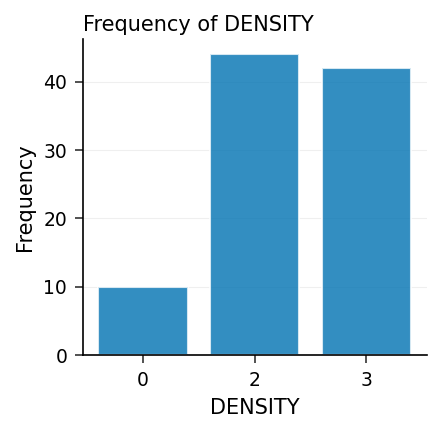

In [2]:
PROCÉDURE GREDUCE DONNÉES=zonemap out=reducedmap;
    id zone;
EXÉCUTER;

PROCÉDURE FRÉQUENCES DONNÉES=reducedmap;
    TABLES DENSITY / nocum;
    ÉTIQUETTE density="Niveau de densité";
    TITRE 'Points de bordure conservés à chaque niveau de DENSITY';
EXÉCUTER;

## Étape 3 — Examiner les paliers de densité

Le tableau de fréquences montre comment GREDUCE a classé les 96 points de contour :

| DENSITY | Points | Part |
|---------|--------|-------|
| 0 | 10 | 10,4 % |
| 2 | 44 | 45,8 % |
| 3 | 42 | 43,8 % |

Seuls 10 points portent le niveau le plus bas (les ancrages de la forme essentielle), tandis que les 86 restants se répartissent entre les niveaux 2 et 3. Pour un palier de tableau de bord, nous gardons tout ce qui est à `DENSITY <= 2` : cela conserve 54 des 96 points, en abandonnant les 42 sommets de détail le plus fin (`DENSITY=3`). Le PROC MEANS ci-dessous confirme que le palier grossier compte 13 à 14 sommets par zone au lieu des 24 d'origine.

In [3]:
PROCÉDURE MOYENNES DONNÉES=reducedmap n;
    CLASSE zone;
    OÙ DENSITY <= 2;
    VAR x;
    ÉTIQUETTE zone="Zone"
              x="Coordonnée X";
    TITRE 'Sommets conservés par zone au niveau de détail du tableau de bord (DENSITY <= 2)';
EXÉCUTER;

                    Sommets conservés par zone au niveau de détail du tableau de bord (DENSITY <= 2)                    

                                                  The MEANS Procedure

                                          Analysis Variable : X Coordonnée X

        Zone              N Obs
        -----------------------
        1                    14
        2                    13
        3                    14
        4                    13
        -----------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Étape 4 — Construire la carte grossière et la réponse de performance par zone

Nous matérialisons le palier de tableau de bord sous `coarsemap` (`DENSITY <= 2`) afin que PROC GMAP puisse dessiner directement le contour réduit. Nous synthétisons aussi une ligne d'indicateur par zone — un **taux de livraison à temps** et un **volume quotidien de colis** — indexée sur `zone` afin que GMAP puisse colorer chaque zone.

In [4]:
DONNÉES coarsemap;
    DÉFINIR reducedmap;
    OÙ DENSITY <= 2;
EXÉCUTER;

DONNÉES zonekpi;
    APPELER streaminit(771);
    FAIRE zone = 1 JUSQU_À 4;
        /* on-time rate centered near 92%, realistic spread */
        ontime_rate = round(88 + 8 * rand('beta', 5, 2), 0.1);
        parcels     = round(2000 + 6000 * rand('uniform'));
        SORTIE;
    FIN;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=zonekpi noobs;
    ÉTIQUETTE zone="Zone"
              ontime_rate="Taux de livraison à temps (%)"
              parcels="Colis par jour";
    TITRE 'Indicateurs de livraison synthétiques par zone';
EXÉCUTER;

                                     Indicateurs de livraison synthétiques par zone                                     

Zone   Taux de livraison à temps (%)  Colis par jour
   1                            92.6            4704
   2                            95.6            2932
   3                            93.4            2934
   4                            94.6            2516




NOTE: DATA coarsemap


NOTE: Read 96 rows from reducedmap.
NOTE: Wrote coarsemap (54 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA zonekpi


NOTE: Wrote zonekpi (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=zonekpi

NOTE: PROC PRINT completed: 4 observations printed, 3 variables


Les quatre taux de livraison à temps synthétiques se situent entre 92,6 % et 95,6 %, avec des volumes quotidiens de colis d'environ 2 500 à 4 700. La zone 2 est la plus performante à 95,6 % ; la zone 1 est la plus faible à 92,6 %. Ce sont ces valeurs que codent les bandes de couleur de la choroplèthe.

## Étape 5 — Restituer les choroplèthes en détail complet et en détail réduit

Nous dessinons deux fois la même choroplèthe de livraison à temps : une fois à partir du `reducedmap` complet à 96 sommets, et une fois à partir du `coarsemap` à 54 sommets. `MAP=` fournit les contours, `DATA=` la réponse d'indicateurs, et les deux partagent l'ID `zone`. L'instruction `CHORO` remplit chaque zone selon `ontime_rate` avec des bandes de couleur `LEVELS=4` et `COUTLINE=` pour des bordures nettes. Comparer les deux cartes montre le coût visuel de la réduction.

                                         Détail complet : 96 sommets de bordure                                         




NOTE: Option TITLE changed to Détail complet : 96 sommets de bordure.
NOTE: PROC GMAP map=reducedmap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable ontime_rate.
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.43 seconds
  cpu   0.43 seconds


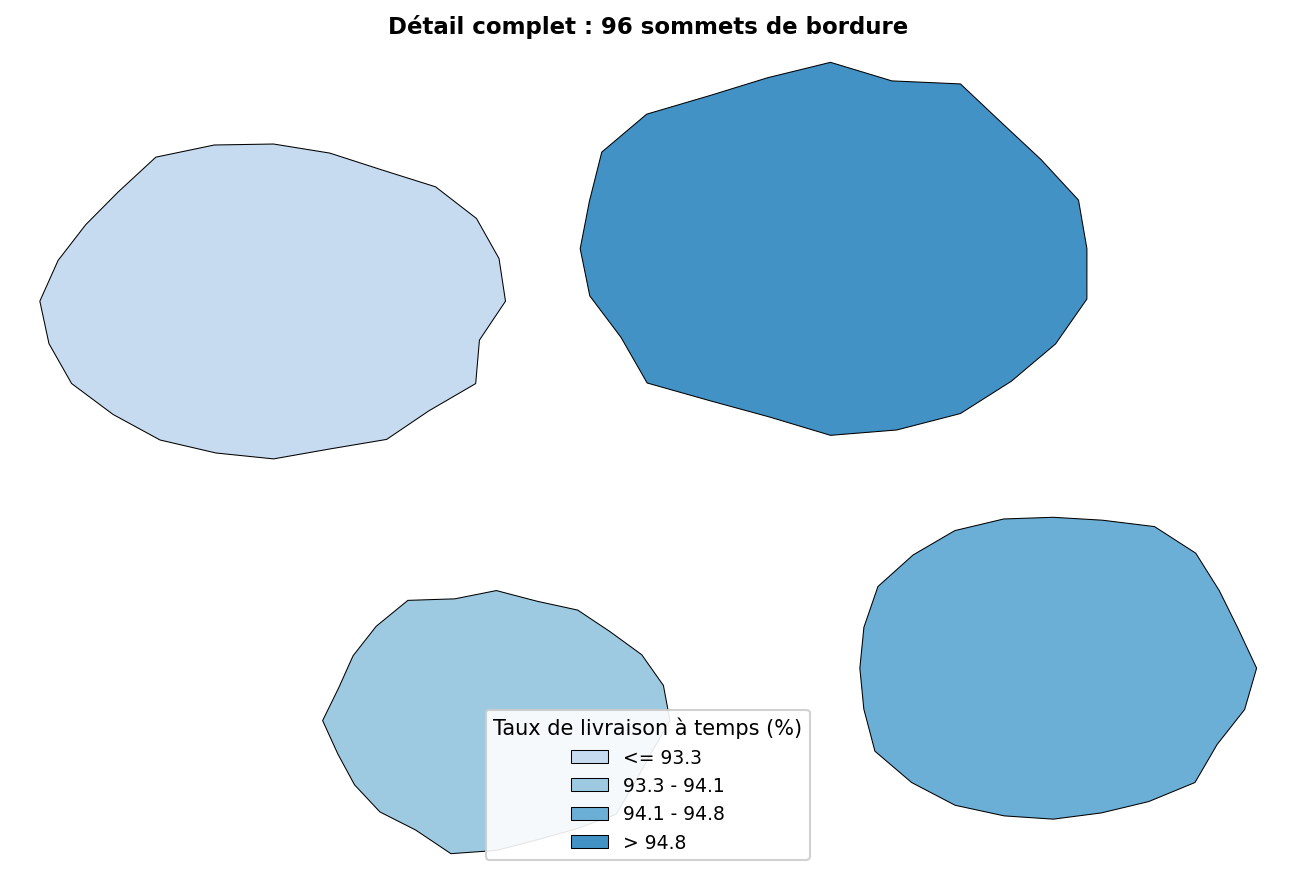

In [5]:
TITRE 'Détail complet : 96 sommets de bordure';
PROCÉDURE GMAP map=reducedmap DONNÉES=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black label="Taux de livraison à temps (%)";
EXÉCUTER;

                                       Détail réduit : 54 sommets (DENSITY <= 2)                                        




NOTE: Option TITLE changed to Détail réduit : 54 sommets (DENSITY <= 2).
NOTE: PROC GMAP map=coarsemap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable ontime_rate.
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.43 seconds
  cpu   0.43 seconds


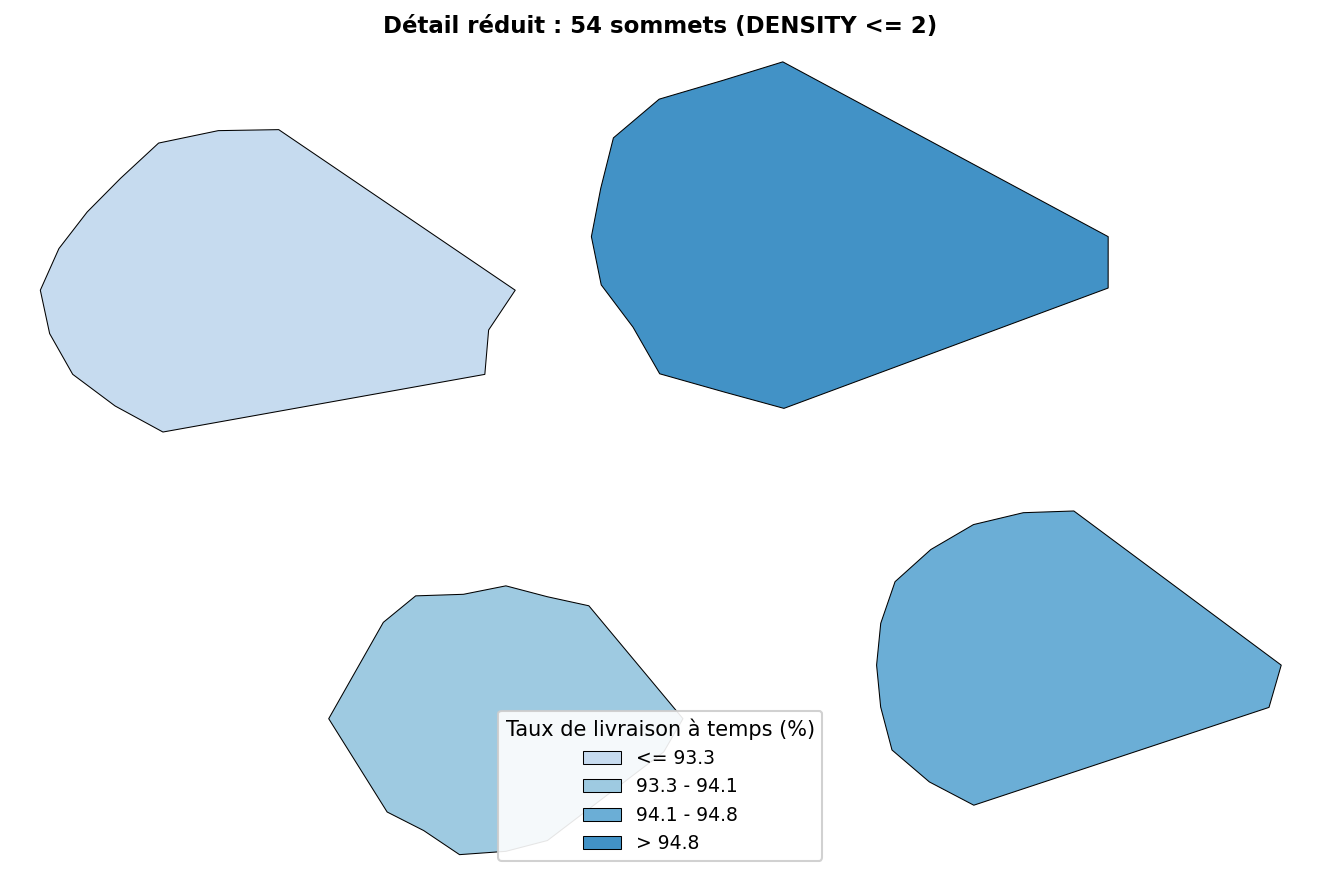

In [6]:
TITRE 'Détail réduit : 54 sommets (DENSITY <= 2)';
PROCÉDURE GMAP map=coarsemap DONNÉES=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black label="Taux de livraison à temps (%)";
EXÉCUTER;

## Interpréter les résultats

PROC GREDUCE a transformé chaque contour de zone à 24 sommets en un ensemble gradué de points de contour (niveaux 0, 2 et 3 dans cette exécution). Sélectionner le palier `DENSITY <= 2` a fait passer la carte de 96 à 54 sommets — soit une réduction de 44 % des points que le moteur de rendu doit dessiner — et pourtant les choroplèthes côte à côte confirment que les quatre zones restent clairement reconnaissables : les contours de la carte réduite sont visiblement plus anguleux, mais chaque territoire garde sa position, sa taille et sa bande de couleur, si bien qu'un opérateur lit le même tableau de bord dans les deux cas.

Ce tableau de bord classe les zones par taux de livraison à temps : la zone 2 mène avec 95,6 % (bande la plus foncée), les zones 3 et 4 se situent dans la moyenne autour de 93–95 %, et la zone 1 est à la traîne à 92,6 % (bande la plus claire) — le territoire qu'un planificateur examinerait en premier pour des problèmes de routage ou de capacité de dépôt.

Comme la réduction n'est pas destructrice — les points en détail complet restent disponibles dans `reducedmap` — le même jeu de données prend en charge à la fois la vue rapide de tableau de bord (`DENSITY <= 2`) et une vue d'impression ou d'audit haute résolution (`DENSITY <= 3`, ou l'ensemble complet) en changeant un seul seuil `WHERE`, sans besoin de réimporter ni de réduire à nouveau la géométrie.